# Generación de visualizaciones en Matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configuración general
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

BASE_DIR = Path("../data/")
EXPORT_DIR = BASE_DIR / "exports"
EXPORT_DIR.mkdir(exist_ok=True)

# Cargamos el dataset del proyecto
df = pd.read_csv(BASE_DIR / "../data/raw/s54a-sgyg.csv")
df["fechaobservacion"] = pd.to_datetime(df["fechaobservacion"], errors="coerce")

print("Dataset cargado correctamente")
print("Dimensiones:", df.shape)
print("Columnas:", list(df.columns))


Dataset cargado correctamente
Dimensiones: (20000, 12)
Columnas: ['codigoestacion', 'codigosensor', 'fechaobservacion', 'valorobservado', 'nombreestacion', 'departamento', 'municipio', 'zonahidrografica', 'latitud', 'longitud', 'descripcionsensor', 'unidadmedida']


## A. Estructura de una gráfica en Matplotlib
En esta sección se muestran figura, ejes, etiquetas, título, leyenda y anotaciones.

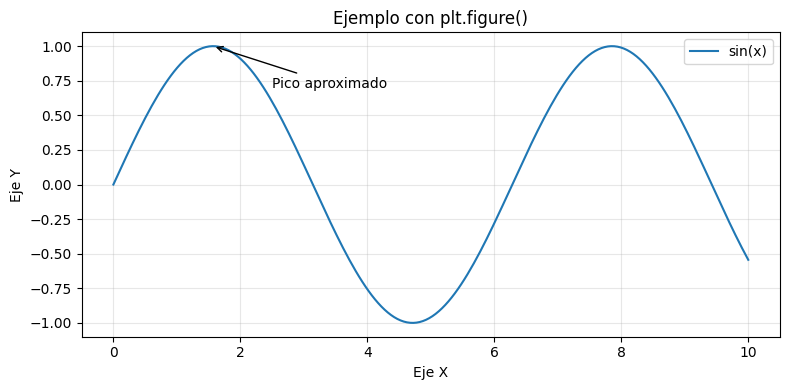

In [2]:
# 1) Crear una figura con plt.figure()
x = np.linspace(0, 10, 200)
y = np.sin(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label="sin(x)")
plt.title("Ejemplo con plt.figure()")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.legend()
plt.annotate("Pico aproximado", xy=(1.57, 1), xytext=(2.5, 0.7),
             arrowprops=dict(arrowstyle="->"))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "01_estructura_figure.png", dpi=200, bbox_inches="tight")
plt.show()


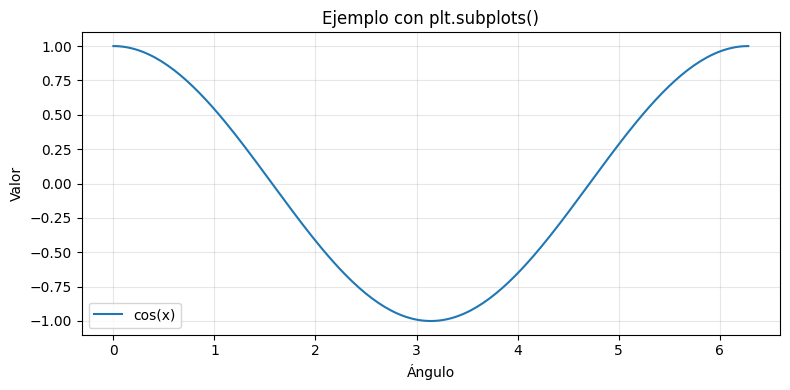

In [3]:
# 2) Crear una figura con plt.subplots()
x = np.linspace(0, 2*np.pi, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, np.cos(x), label="cos(x)")
ax.set_title("Ejemplo con plt.subplots()")
ax.set_xlabel("Ángulo")
ax.set_ylabel("Valor")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


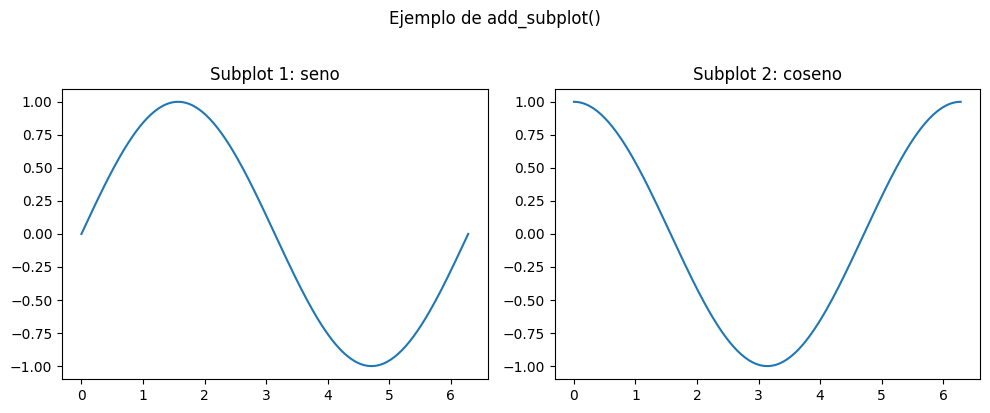

In [4]:
# 3) Crear ejes con add_subplot()
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(x, np.sin(x))
ax1.set_title("Subplot 1: seno")

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x, np.cos(x))
ax2.set_title("Subplot 2: coseno")

fig.suptitle("Ejemplo de add_subplot()", y=1.02)
fig.tight_layout()
plt.show()


## B. Interfaz `pyplot` vs interfaz orientada a objetos (OO)

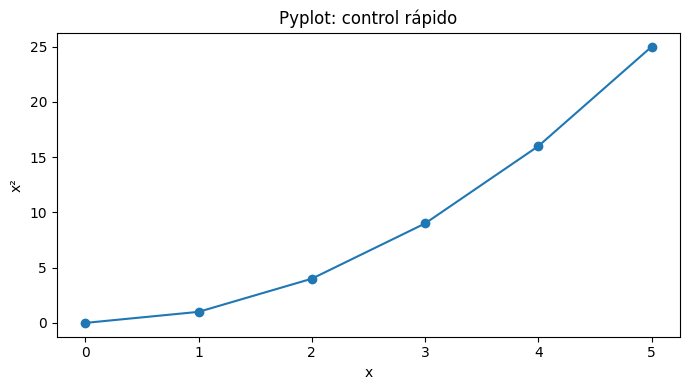

In [5]:
# 4) Ejemplo básico con pyplot
x = np.arange(0, 6)
y = x ** 2

plt.figure(figsize=(7, 4))
plt.plot(x, y, marker="o")
plt.title("Pyplot: control rápido")
plt.xlabel("x")
plt.ylabel("x²")
plt.tight_layout()
plt.show()


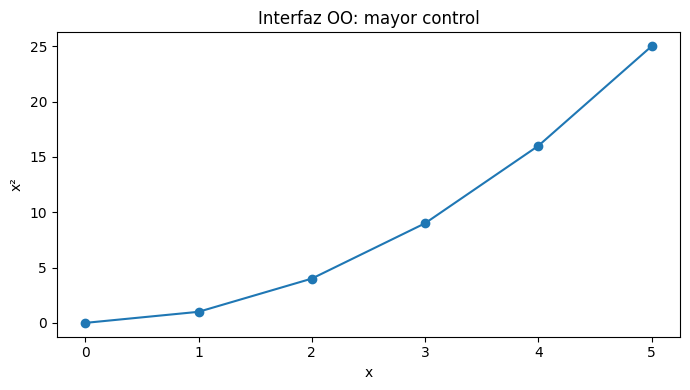

In [6]:
# 5) Ejemplo OO con fig, ax = plt.subplots()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, marker="o")
ax.set_title("Interfaz OO: mayor control")
ax.set_xlabel("x")
ax.set_ylabel("x²")
fig.tight_layout()
plt.show()


## C. Gráficas univariantes

In [7]:
# Datos base para gráficas univariantes
np.random.seed(42)
datos_uni = np.random.normal(loc=50, scale=12, size=500)


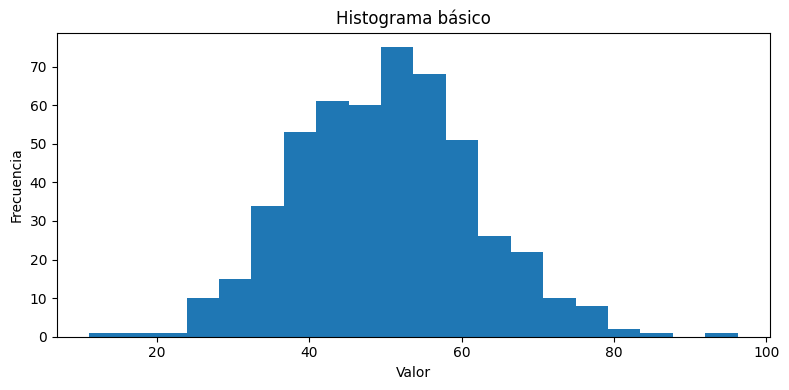

In [8]:
# 1) Histograma básico
plt.figure(figsize=(8, 4))
plt.hist(datos_uni, bins=20)
plt.title("Histograma básico")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "02_histograma_basico.png", dpi=200, bbox_inches="tight")
plt.show()


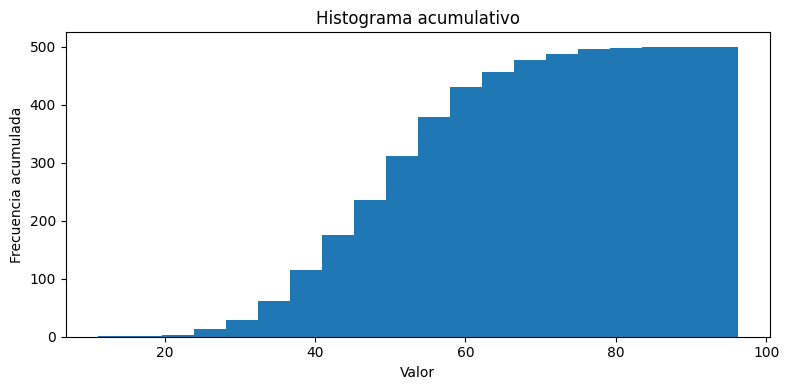

In [9]:
# 2) Histograma acumulativo
plt.figure(figsize=(8, 4))
plt.hist(datos_uni, bins=20, cumulative=True)
plt.title("Histograma acumulativo")
plt.xlabel("Valor")
plt.ylabel("Frecuencia acumulada")
plt.tight_layout()
plt.show()


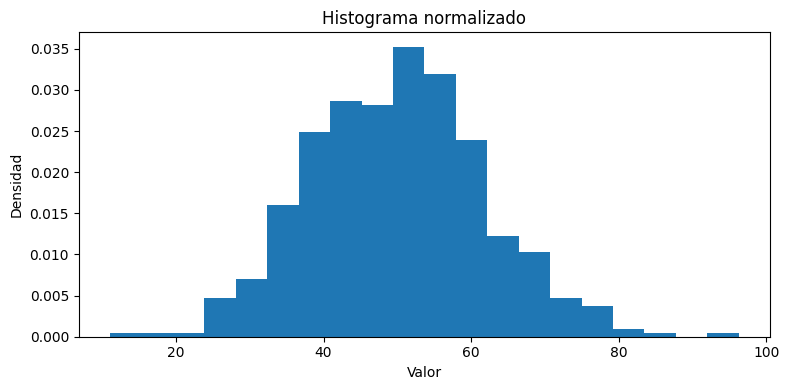

In [10]:
# 3) Histograma normalizado
plt.figure(figsize=(8, 4))
plt.hist(datos_uni, bins=20, density=True)
plt.title("Histograma normalizado")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.tight_layout()
plt.show()


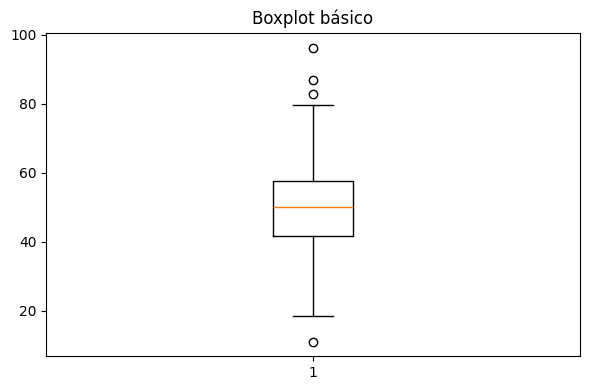

In [11]:
# 4) Boxplot básico
plt.figure(figsize=(6, 4))
plt.boxplot(datos_uni)
plt.title("Boxplot básico")
plt.tight_layout()
plt.show()


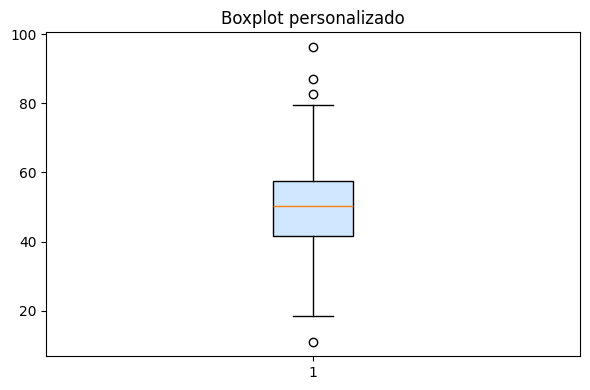

In [12]:
# 5) Boxplot personalizado con colores
fig, ax = plt.subplots(figsize=(6, 4))
bp = ax.boxplot(datos_uni, patch_artist=True)
for box in bp["boxes"]:
    box.set(facecolor="#cfe8ff")
ax.set_title("Boxplot personalizado")
fig.tight_layout()
plt.show()


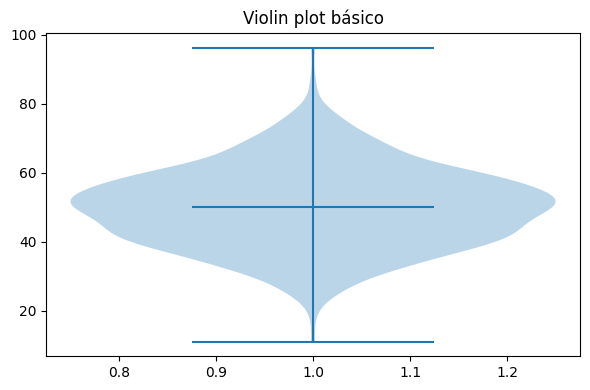

In [13]:
# 6) Violin plot básico
plt.figure(figsize=(6, 4))
plt.violinplot(datos_uni, showmeans=True)
plt.title("Violin plot básico")
plt.tight_layout()
plt.show()


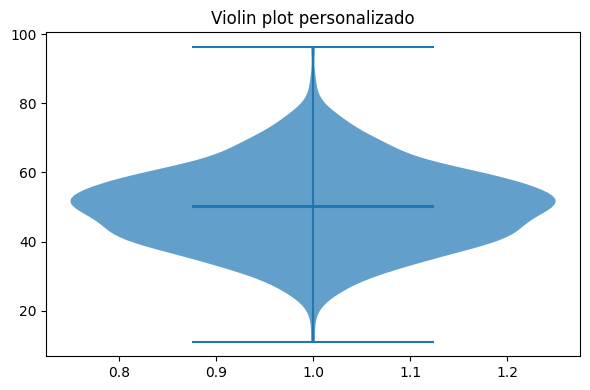

In [14]:
# 7) Violin plot personalizado
fig, ax = plt.subplots(figsize=(6, 4))
parts = ax.violinplot(datos_uni, showmeans=True, showmedians=True)
for body in parts["bodies"]:
    body.set_alpha(0.7)
ax.set_title("Violin plot personalizado")
fig.tight_layout()
plt.show()


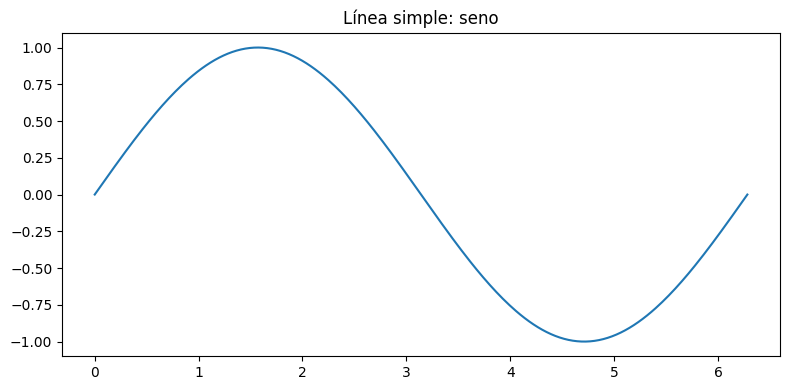

In [15]:
# 8) Gráfica de línea simple (seno)
x = np.linspace(0, 2*np.pi, 300)
plt.figure(figsize=(8, 4))
plt.plot(x, np.sin(x))
plt.title("Línea simple: seno")
plt.tight_layout()
plt.show()


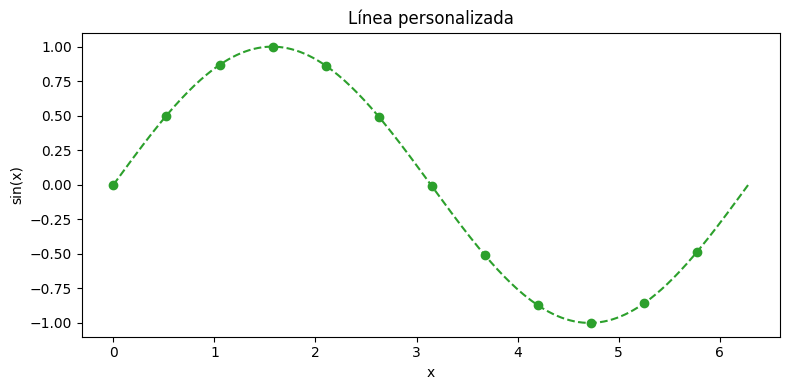

In [16]:
# 9) Gráfica de línea personalizada
plt.figure(figsize=(8, 4))
plt.plot(x, np.sin(x), color="tab:green", linestyle="--", marker="o", markevery=25)
plt.title("Línea personalizada")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.tight_layout()
plt.show()


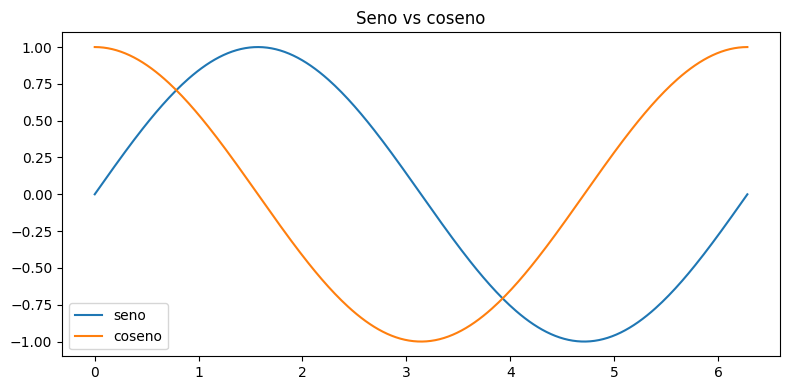

In [17]:
# 10) Línea comparativa: seno vs coseno
plt.figure(figsize=(8, 4))
plt.plot(x, np.sin(x), label="seno")
plt.plot(x, np.cos(x), label="coseno")
plt.title("Seno vs coseno")
plt.legend()
plt.tight_layout()
plt.show()


## D. Gráficas bivariantes

In [18]:
# Datos base para gráficas bivariantes
np.random.seed(7)
x_bi = np.linspace(0, 100, 150)
y_bi = 2.5 * x_bi + np.random.normal(0, 25, 150)
tamanos = np.random.randint(20, 200, size=150)
colores = np.random.rand(150)


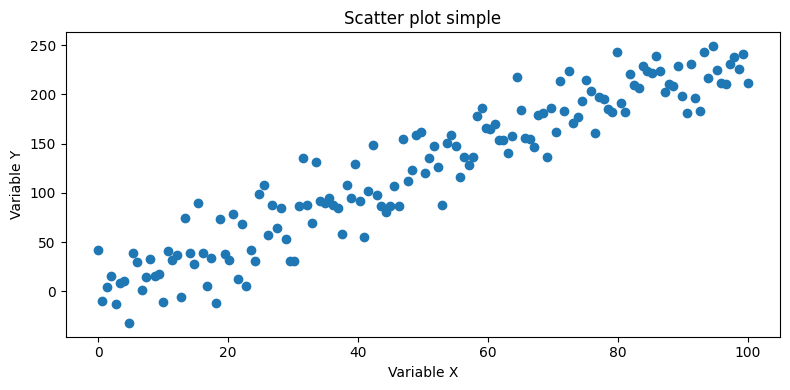

In [19]:
# 1) Scatter plot simple
plt.figure(figsize=(8, 4))
plt.scatter(x_bi, y_bi)
plt.title("Scatter plot simple")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.tight_layout()
plt.show()


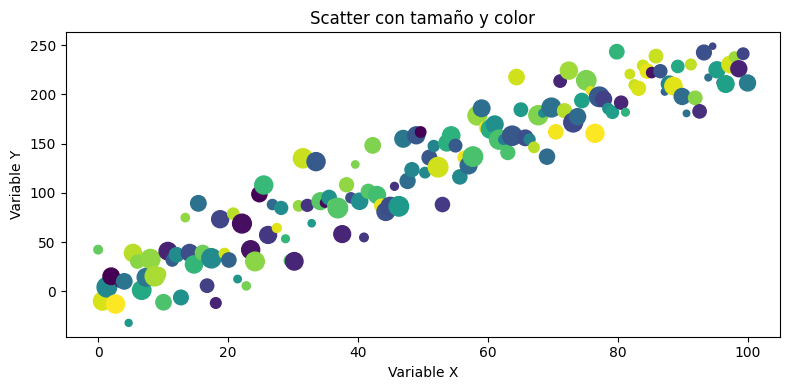

In [20]:
# 2) Scatter con tamaño y color
plt.figure(figsize=(8, 4))
plt.scatter(x_bi, y_bi, s=tamanos, c=colores)
plt.title("Scatter con tamaño y color")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.tight_layout()
plt.show()


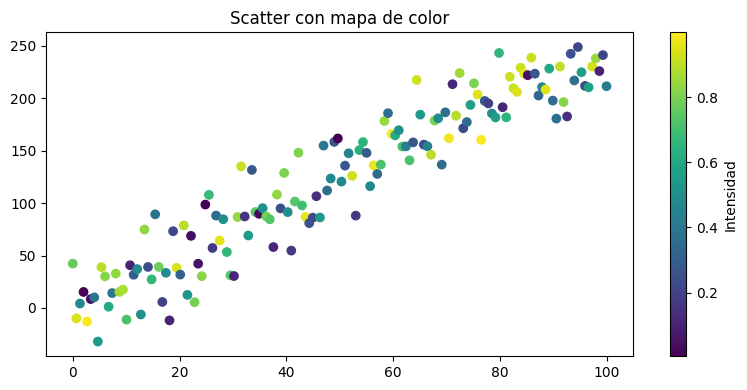

In [21]:
# 3) Scatter con mapa de color
plt.figure(figsize=(8, 4))
sc = plt.scatter(x_bi, y_bi, c=colores, cmap="viridis")
plt.colorbar(sc, label="Intensidad")
plt.title("Scatter con mapa de color")
plt.tight_layout()
plt.show()


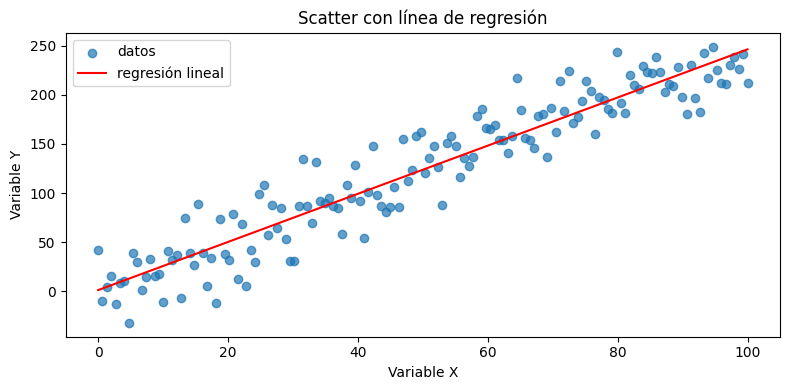

In [22]:
# 4) Scatter con línea de regresión
coef = np.polyfit(x_bi, y_bi, 1)
regresion = np.poly1d(coef)

plt.figure(figsize=(8, 4))
plt.scatter(x_bi, y_bi, alpha=0.7, label="datos")
plt.plot(x_bi, regresion(x_bi), color="red", label="regresión lineal")
plt.title("Scatter con línea de regresión")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "03_scatter_regresion.png", dpi=200, bbox_inches="tight")
plt.show()


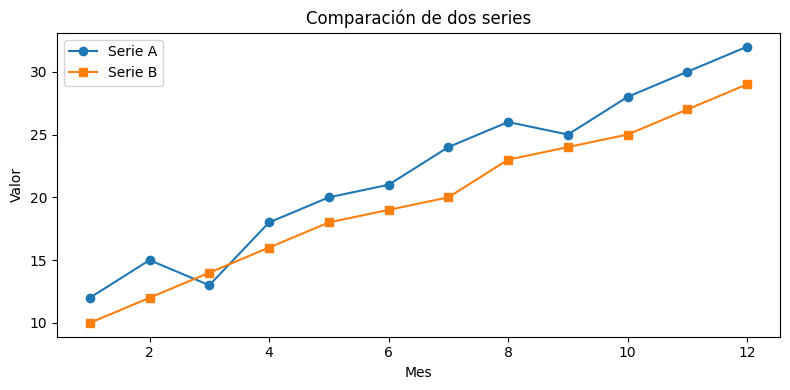

In [23]:
# 5) Gráfica de línea comparativa de dos variables
x_linea = np.arange(1, 13)
ventas_a = np.array([12, 15, 13, 18, 20, 21, 24, 26, 25, 28, 30, 32])
ventas_b = np.array([10, 12, 14, 16, 18, 19, 20, 23, 24, 25, 27, 29])

plt.figure(figsize=(8, 4))
plt.plot(x_linea, ventas_a, marker="o", label="Serie A")
plt.plot(x_linea, ventas_b, marker="s", label="Serie B")
plt.title("Comparación de dos series")
plt.xlabel("Mes")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()


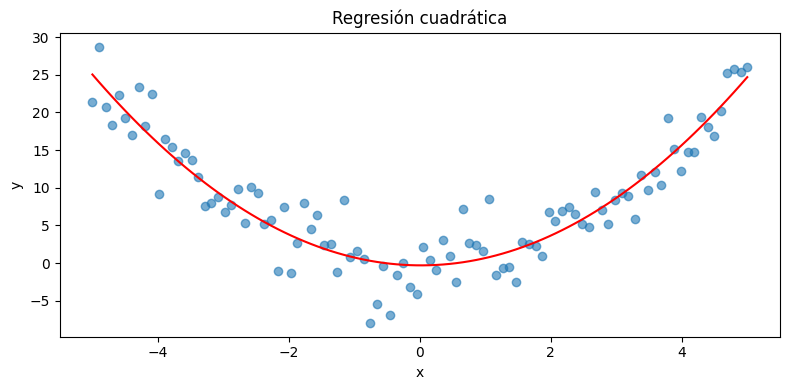

In [24]:
# 6) Línea con regresión cuadrática
xq = np.linspace(-5, 5, 100)
yq = xq**2 + np.random.normal(0, 3, 100)
coef_q = np.polyfit(xq, yq, 2)
modelo_q = np.poly1d(coef_q)

plt.figure(figsize=(8, 4))
plt.scatter(xq, yq, alpha=0.6)
plt.plot(xq, modelo_q(xq), color="red")
plt.title("Regresión cuadrática")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


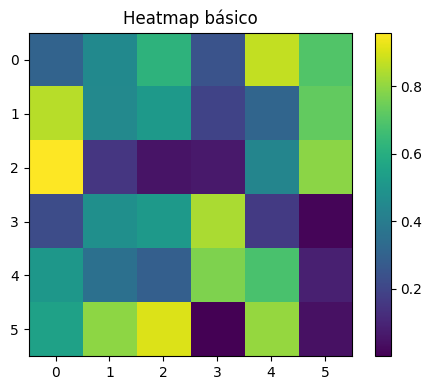

In [25]:
# 7) Heatmap básico con imshow()
matriz = np.random.rand(6, 6)

plt.figure(figsize=(5, 4))
plt.imshow(matriz)
plt.title("Heatmap básico")
plt.colorbar()
plt.tight_layout()
plt.show()


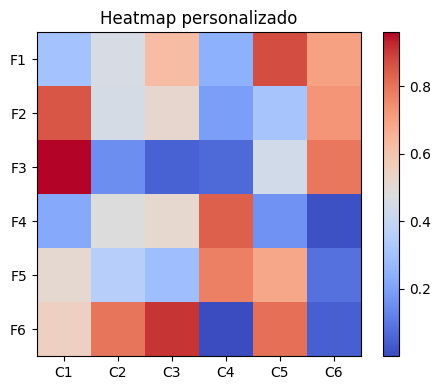

In [26]:
# 8) Heatmap personalizado
plt.figure(figsize=(5, 4))
plt.imshow(matriz, cmap="coolwarm", interpolation="nearest")
plt.xticks(range(6), [f"C{i}" for i in range(1, 7)])
plt.yticks(range(6), [f"F{i}" for i in range(1, 7)])
plt.title("Heatmap personalizado")
plt.colorbar()
plt.tight_layout()
plt.show()


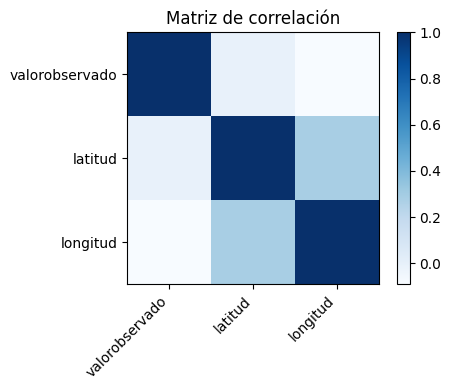

In [27]:
# 9) Heatmap de matriz de correlación con el dataset del proyecto
corr = df[["valorobservado", "latitud", "longitud"]].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="Blues")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)), corr.index)
ax.set_title("Matriz de correlación")
fig.colorbar(im)
fig.tight_layout()
plt.savefig(EXPORT_DIR / "04_heatmap_correlacion.png", dpi=200, bbox_inches="tight")
plt.show()


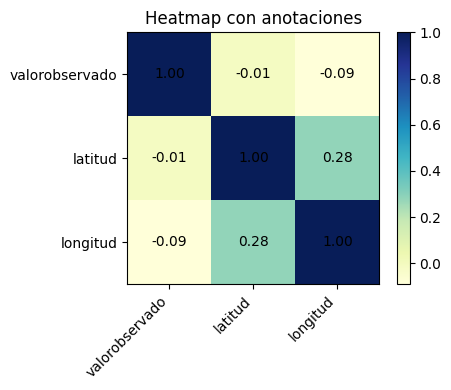

In [28]:
# 10) Heatmap con anotaciones numéricas
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="YlGnBu")

ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_title("Heatmap con anotaciones")
fig.colorbar(im)
fig.tight_layout()
plt.show()


## E. Gráficas categóricas

In [29]:
# Datos base para gráficas categóricas
categorias = ["Norte", "Sur", "Este", "Oeste"]
producto_a = np.array([20, 25, 18, 22])
producto_b = np.array([15, 18, 20, 17])
producto_c = np.array([10, 12, 14, 13])


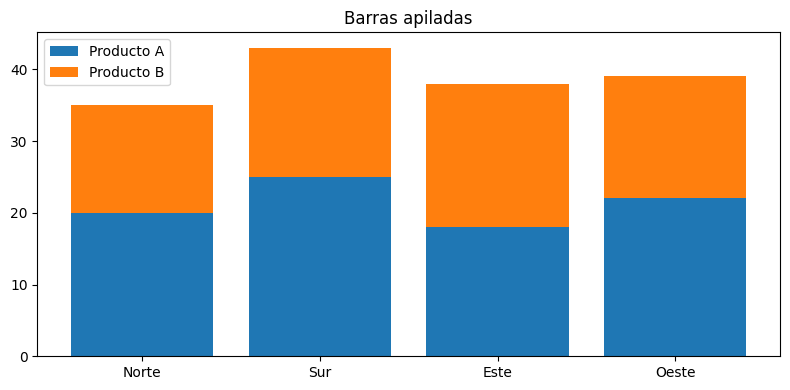

In [30]:
# 1) Barras apiladas
plt.figure(figsize=(8, 4))
plt.bar(categorias, producto_a, label="Producto A")
plt.bar(categorias, producto_b, bottom=producto_a, label="Producto B")
plt.title("Barras apiladas")
plt.legend()
plt.tight_layout()
plt.show()


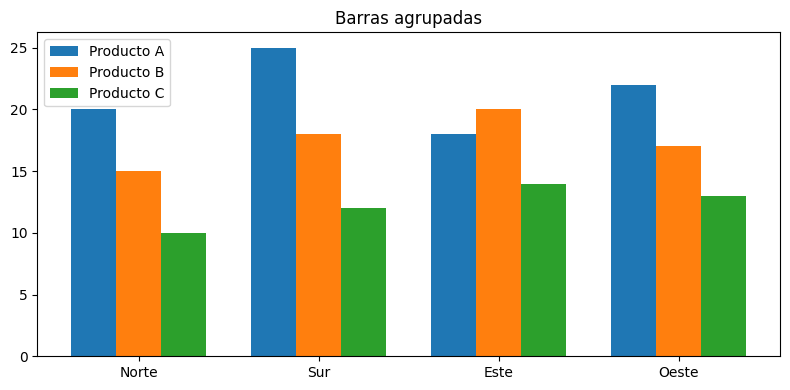

In [31]:
# 2) Barras agrupadas
x_pos = np.arange(len(categorias))
ancho = 0.25

plt.figure(figsize=(8, 4))
plt.bar(x_pos - ancho, producto_a, width=ancho, label="Producto A")
plt.bar(x_pos, producto_b, width=ancho, label="Producto B")
plt.bar(x_pos + ancho, producto_c, width=ancho, label="Producto C")
plt.xticks(x_pos, categorias)
plt.title("Barras agrupadas")
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "05_barras_agrupadas.png", dpi=200, bbox_inches="tight")
plt.show()


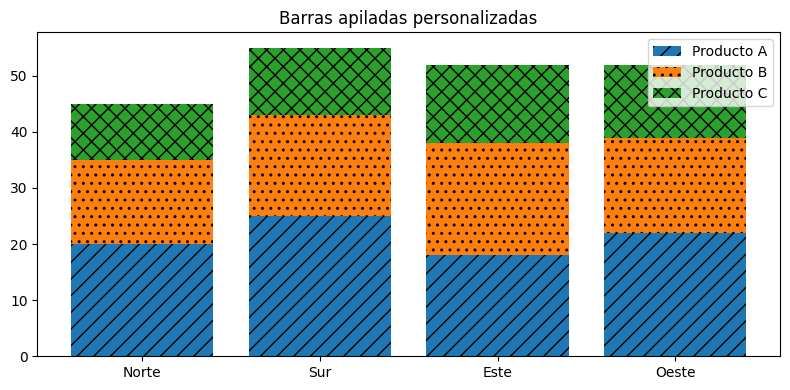

In [32]:
# 3) Barras apiladas personalizadas
plt.figure(figsize=(8, 4))
plt.bar(categorias, producto_a, label="Producto A", hatch="//")
plt.bar(categorias, producto_b, bottom=producto_a, label="Producto B", hatch="..")
plt.bar(categorias, producto_c, bottom=producto_a + producto_b, label="Producto C", hatch="xx")
plt.title("Barras apiladas personalizadas")
plt.legend()
plt.tight_layout()
plt.show()


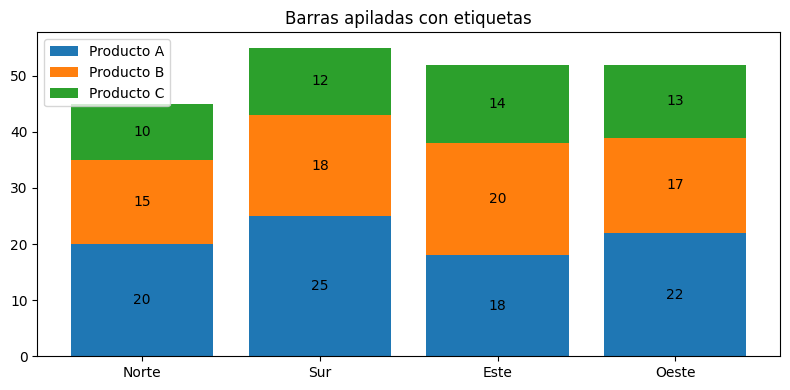

In [33]:
# 4) Barras con etiquetas numéricas en cada segmento
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(categorias, producto_a, label="Producto A")
b2 = ax.bar(categorias, producto_b, bottom=producto_a, label="Producto B")
b3 = ax.bar(categorias, producto_c, bottom=producto_a + producto_b, label="Producto C")

for barras in [b1, b2, b3]:
    ax.bar_label(barras, label_type="center")

ax.set_title("Barras apiladas con etiquetas")
ax.legend()
fig.tight_layout()
plt.show()


## F. Aplicación al dataset del proyecto personal (`s54a-sgyg.csv`)

In [34]:
# Vista rápida del dataset
df.head()


,codigoestacion,codigosensor,fechaobservacion,valorobservado,nombreestacion,departamento,municipio,zonahidrografica,latitud,longitud,descripcionsensor,unidadmedida
0,2906500077,240,2019-08-17 16:20:00,0.0,PALMOR - SIERRA NEVADA - AUT,MAGDALENA,CIÉNAGA,BAJO MAGDALENA,10.771750,-74.019139,Precipitacion,mm
1,25025030,240,2017-08-18 11:20:00,0.0,AYAPEL,CÓRDOBA,AYAPEL,BAJO MAGDALENA- CAUCA -SAN JORGE,8.295000,-75.165000,Precipitacion,mm
2,23197690,240,2013-10-07 07:40:00,0.0,PALOGORDO - AUT,SANTANDER,GIRÓN,MEDIO MAGDALENA,6.969167,-73.130556,Precipitacion,mm
3,24025090,240,2013-08-02 05:20:00,0.0,MOGOTES - AUT,SANTANDER,MOGOTES,SOGAMOSO,6.470000,-72.968889,Precipitacion,mm
4,21206280,240,2019-07-08 21:50:00,0.0,ACAPULCO,CUNDINAMARCA,BOJACÁ,ALTO MAGDALENA,4.653833,-74.333056,Precipitacion,mm


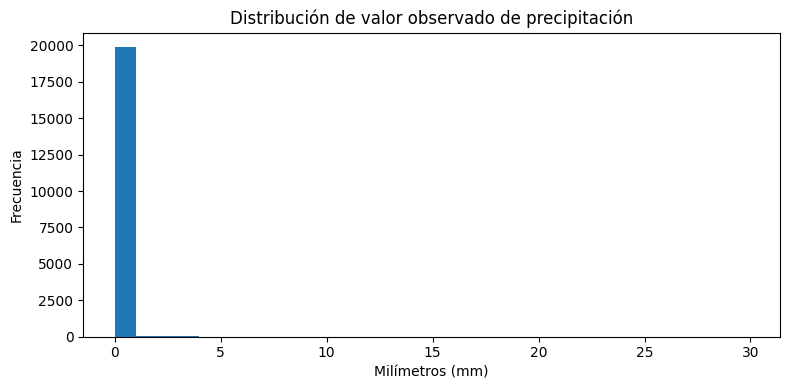

In [35]:
# Histograma de precipitación observada
plt.figure(figsize=(8, 4))
plt.hist(df["valorobservado"], bins=30)
plt.title("Distribución de valor observado de precipitación")
plt.xlabel("Milímetros (mm)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "06_precipitacion_histograma.png", dpi=200, bbox_inches="tight")
plt.show()


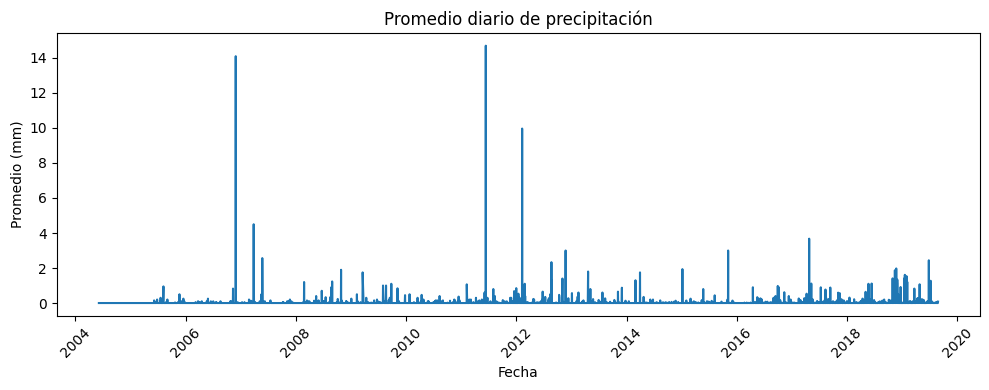

In [36]:
# Serie temporal: promedio diario de precipitación
serie_diaria = df.groupby(df["fechaobservacion"].dt.date)["valorobservado"].mean()

plt.figure(figsize=(10, 4))
plt.plot(serie_diaria.index, serie_diaria.values)
plt.title("Promedio diario de precipitación")
plt.xlabel("Fecha")
plt.ylabel("Promedio (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "07_precipitacion_linea.png", dpi=200, bbox_inches="tight")
plt.savefig(EXPORT_DIR / "07_precipitacion_linea.pdf", bbox_inches="tight")
plt.show()


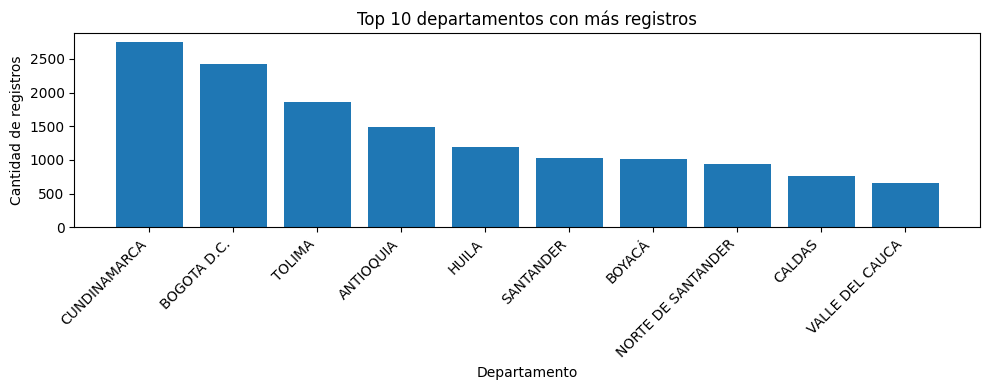

In [37]:
# Barras: top 10 departamentos con más registros
top_dep = df["departamento"].value_counts().head(10)

plt.figure(figsize=(10, 4))
plt.bar(top_dep.index, top_dep.values)
plt.title("Top 10 departamentos con más registros")
plt.xlabel("Departamento")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


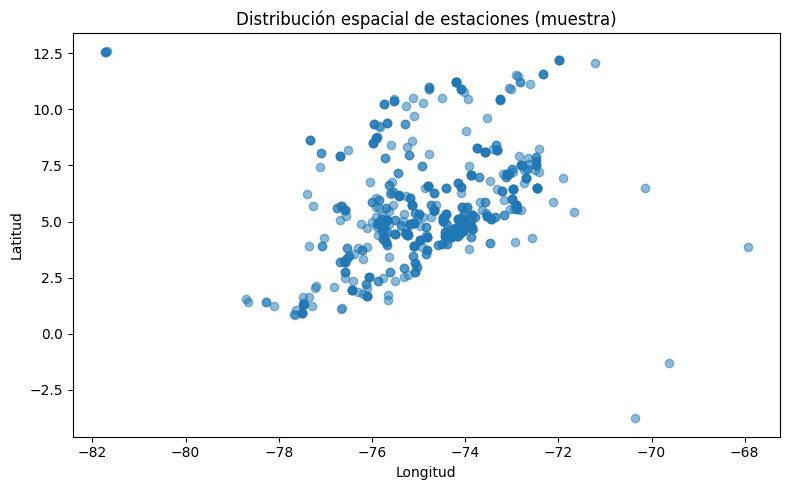

In [38]:
# Dispersión geográfica simple con muestra
muestra = df.sample(700, random_state=10)

plt.figure(figsize=(8, 5))
plt.scatter(muestra["longitud"], muestra["latitud"], alpha=0.5)
plt.title("Distribución espacial de estaciones (muestra)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show()
